# 03 - Exploratory Data Analysis

## Project

MaternalRisk: Early Prediction of Gestational Diabetes Using Explainable Machine Learning

**Author:** Kristen Cranford

**Date:** July 2026

---

# Objective

The objective of this notebook is to explore the clinical and statistical characteristics of the processed dataset prior to feature engineering and model development.

The analysis investigates the distribution of predictor variables, relationships with gestational diabetes, and relationships among clinical features. Findings from this exploratory analysis will guide subsequent feature engineering and modeling decisions.

# Background

The dataset has undergone an initial data quality assessment and preprocessing strategy, resulting in a cleaned dataset suitable for exploratory analysis.

Exploratory data analysis (EDA) is used to better understand the characteristics of the patient population, identify meaningful relationships between predictors and gestational diabetes, and detect patterns that may influence model performance.

The goal of this notebook is not to draw causal conclusions, but to identify clinically relevant trends that warrant further investigation during model development.

# Workflow

This notebook follows the exploratory analysis workflow below:

1. Load the processed dataset.
2. Examine the target variable.
3. Explore individual predictor distributions.
4. Compare predictors across gestational diabetes outcomes.
5. Investigate relationships among predictors.
6. Summarize clinically relevant findings.
7. Identify implications for feature engineering and model development.

In [83]:
# Load Data
from pathlib import Path
from IPython.display import HTML, display

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/processed/gdm_clean.parquet")

df = pd.read_parquet(DATA_PATH)

df.head()

,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM),Missing Count
0,22,2,1,NaN,55.0,0,0,0,0,102.0,69,NaN,12.0,0,0,0,2
1,26,2,1,NaN,53.0,0,0,0,0,101.0,63,NaN,12.4,0,0,0,2
2,29,1,0,NaN,50.0,0,0,0,0,118.0,79,NaN,14.3,0,0,0,2
3,28,2,1,NaN,51.0,0,0,0,0,99.0,70,NaN,15.0,0,0,0,2
4,21,2,1,NaN,52.0,0,0,0,0,116.0,65,NaN,15.0,0,0,0,2


## Investigation 1 — Target Variable

## Question

What is the distribution of the target variable?

In [84]:
target = "Class Label(GDM /Non GDM)"

counts = df[target].value_counts()

percentages = (
    df[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(counts)
display(percentages)

Class Label(GDM /Non GDM)
0    2153
1    1372
Name: count, dtype: int64

Class Label(GDM /Non GDM)
0    61.08
1    38.92
Name: proportion, dtype: float64

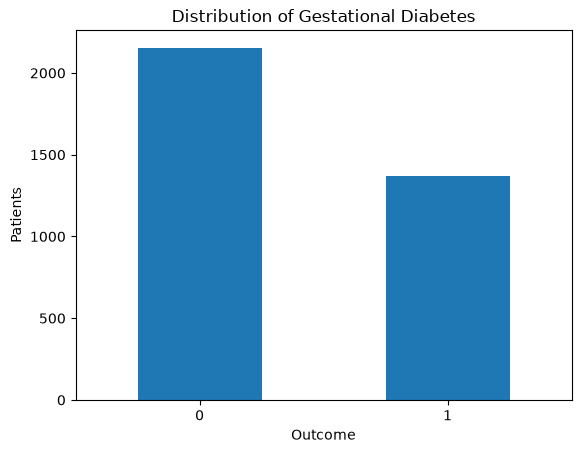

In [85]:
counts.plot(kind="bar")

plt.title("Distribution of Gestational Diabetes")
plt.xlabel("Outcome")
plt.ylabel("Patients")

plt.xticks(rotation=0)

plt.show()

## Interpretation

Approximately 39% of pregnancies were diagnosed with gestational diabetes, while 61% were classified as non-GDM. Although the classes are not perfectly balanced, the imbalance is moderate rather than extreme. Stratified sampling should therefore be used during train-test splitting to preserve class proportions, and model performance should be evaluated using metrics such as precision, recall, F1-score, and ROC-AUC in addition to overall accuracy.

## Key Finding 1 — Target Variable

The dataset contains a moderate class imbalance, with approximately 39% of pregnancies diagnosed with gestational diabetes. This imbalance is not severe but should be considered during model development through stratified data splitting and evaluation using metrics beyond overall accuracy.

## Investigation 2 — Continuous Variables

## Question

What are the distributions of the continuous clinical variables?


Age


count    3525.000000
mean       32.581277
std         6.169107
min        20.000000
25%        28.000000
50%        32.000000
75%        37.000000
max        45.000000
Name: Age, dtype: float64

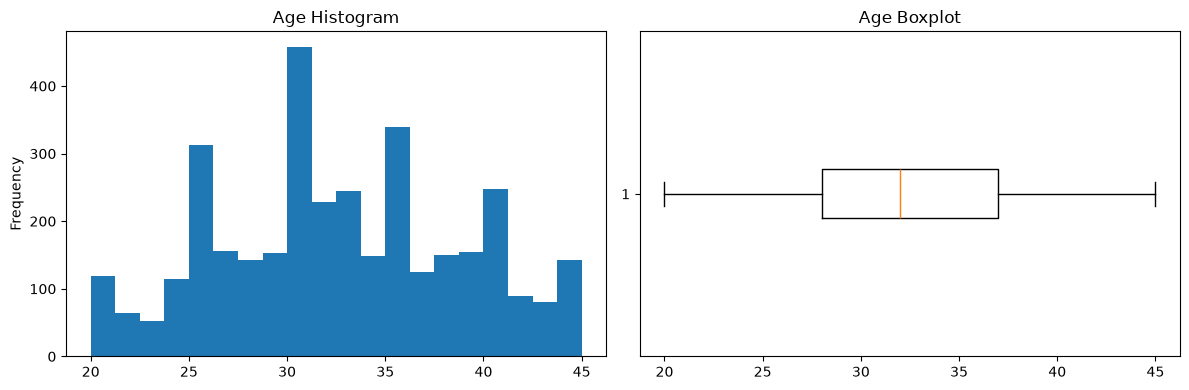


BMI


count    2444.000000
mean       27.854092
std         5.714737
min        13.300000
25%        24.400000
50%        27.500000
75%        31.000000
max        45.000000
Name: BMI, dtype: float64

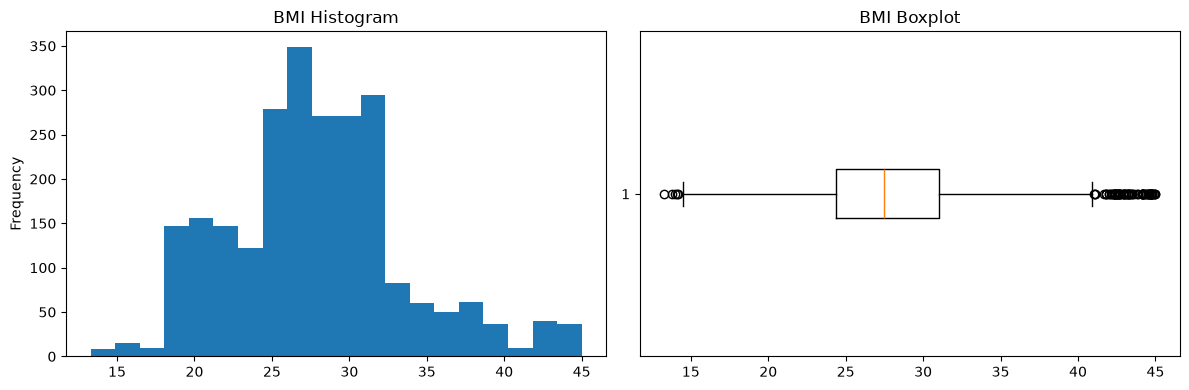


HDL


count    2524.000000
mean       46.471870
std        10.800813
min        15.000000
25%        42.000000
50%        49.000000
75%        55.000000
max        70.000000
Name: HDL, dtype: float64

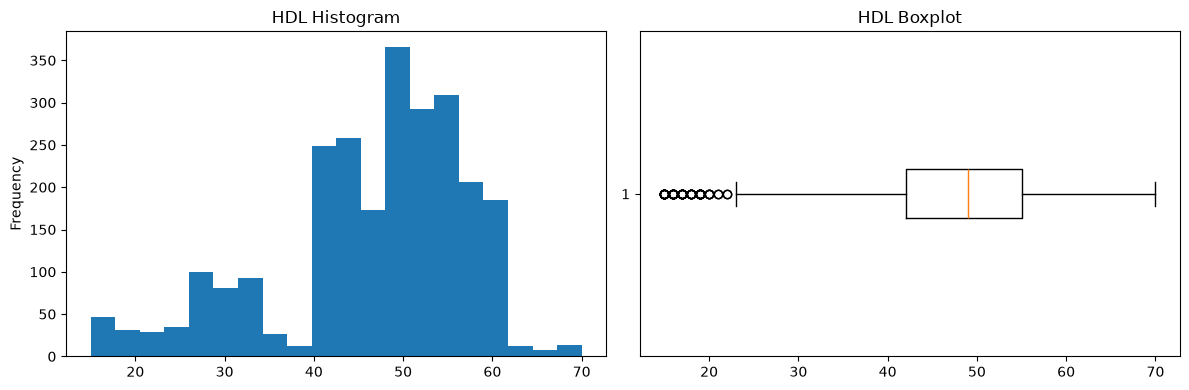


Sys BP


count    1820.000000
mean      135.762088
std        22.742844
min        90.000000
25%       122.000000
50%       132.000000
75%       153.000000
max       185.000000
Name: Sys BP, dtype: float64

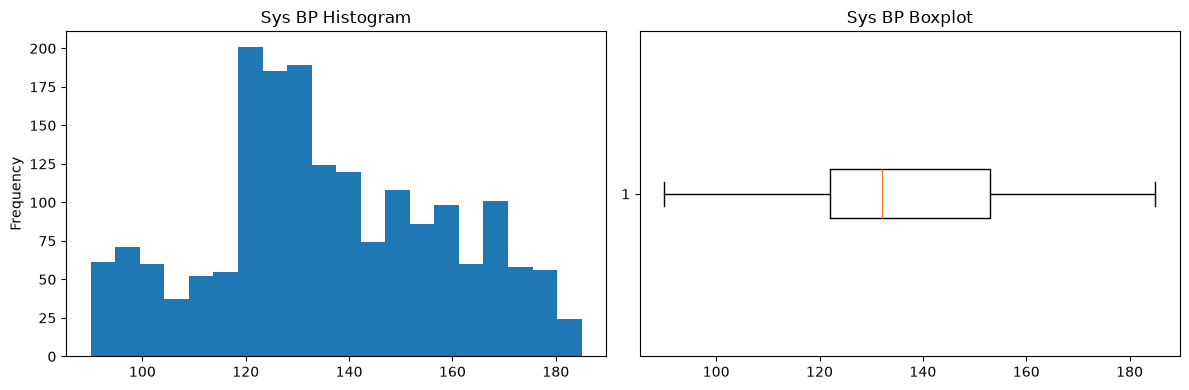


Dia BP


count    3525.000000
mean       81.538156
std        11.379758
min        60.000000
25%        74.000000
50%        81.000000
75%        86.000000
max       124.000000
Name: Dia BP, dtype: float64

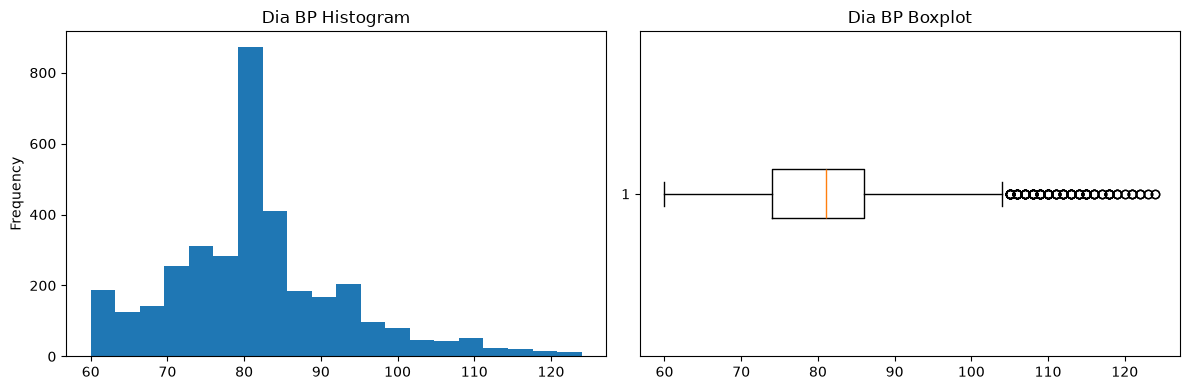


Hemoglobin


count    3525.000000
mean       13.959801
std         1.863969
min         8.800000
25%        12.700000
50%        14.000000
75%        15.000000
max        18.000000
Name: Hemoglobin, dtype: float64

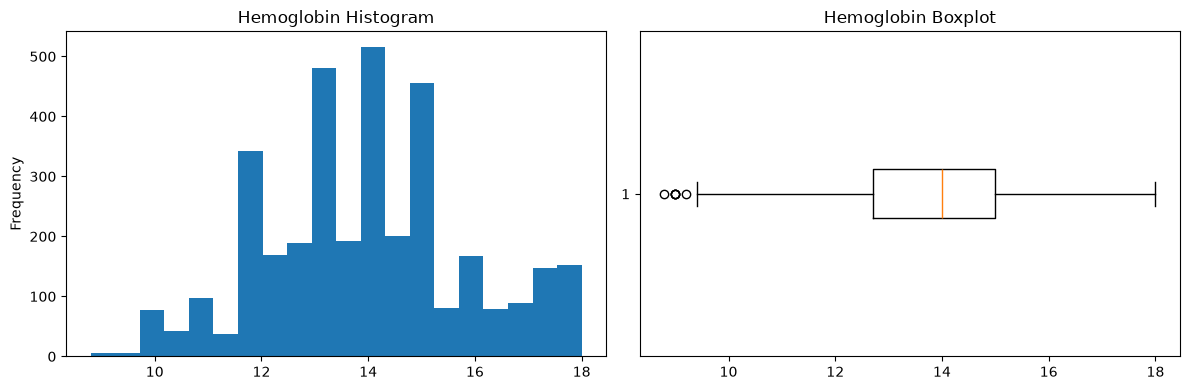


OGTT


count    3012.000000
mean      170.707503
std        48.160549
min        80.000000
25%       142.000000
50%       156.000000
75%       195.000000
max       403.000000
Name: OGTT, dtype: float64

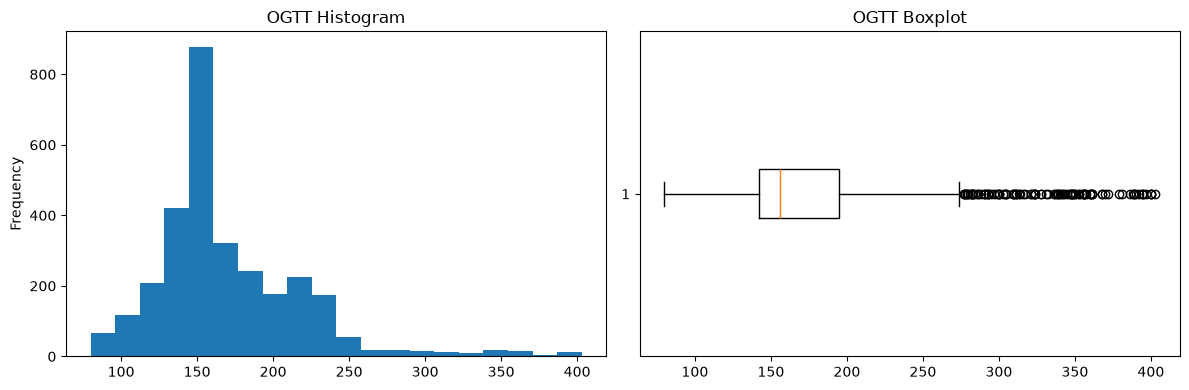

In [86]:
continuous = [
    "Age",
    "BMI",
    "HDL",
    "Sys BP",
    "Dia BP",
    "Hemoglobin",
    "OGTT"
]

for col in continuous:

    print("\n" + "=" * 60)
    print(col)

    display(df[col].describe())

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    df[col].plot.hist(ax=ax[0], bins=20)
    ax[0].set_title(f"{col} Histogram")

    ax[1].boxplot(df[col].dropna(), orientation="horizontal")
    ax[1].set_title(f"{col} Boxplot")

    plt.tight_layout()

    plt.show()

## Interpretation

Visual inspection of the continuous variables indicates that the clinical measurements span physiologically plausible ranges and exhibit varying distributional characteristics.

Maternal age and hemoglobin appear approximately symmetric, while BMI and diastolic blood pressure demonstrate mild positive skew. HDL cholesterol exhibits a slight concentration toward higher values with several lower observations, and systolic blood pressure displays considerable variability across the cohort. Although several variables contain statistical outliers according to the boxplots, these observations remain clinically plausible and are consistent with the decision made during data quality assessment to retain all records.

Overall, the distributions do not suggest major data quality concerns and provide useful insight into the variability present within the study population.

## Key Finding 2 — Continuous Variables

The continuous clinical variables exhibit clinically plausible distributions with varying degrees of variability and skewness. Several variables contain statistical outliers; however, these observations fall within reasonable physiological ranges and were retained for subsequent analysis. These findings support the use of the cleaned dataset for exploratory analysis and downstream predictive modeling.

## Investigation 3 — Binary Variables

## Question

How common are each of the binary clinical risk factors?

Family History
0    1769
1    1756
Name: count, dtype: int64

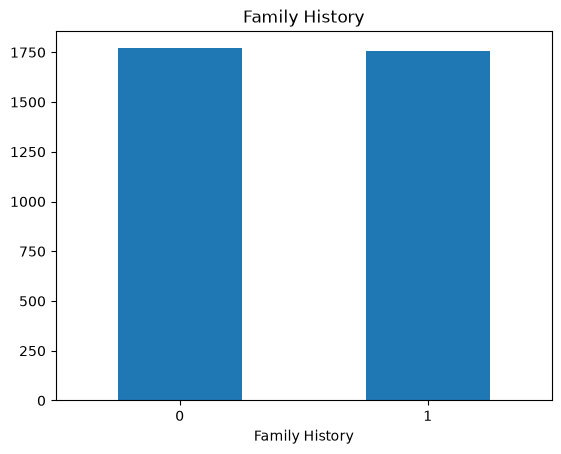

unexplained prenetal loss
0    2239
1    1286
Name: count, dtype: int64

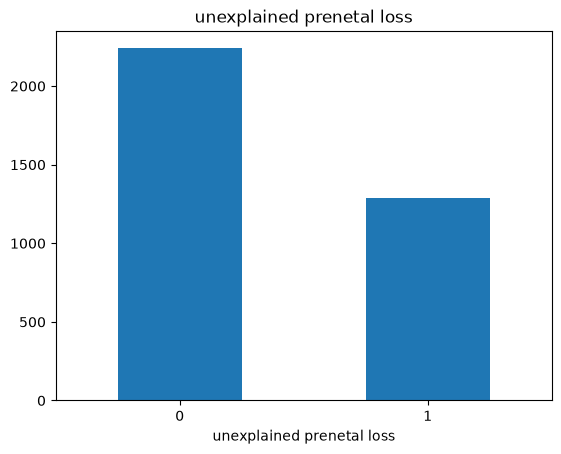

Large Child or Birth Default
0    2264
1    1261
Name: count, dtype: int64

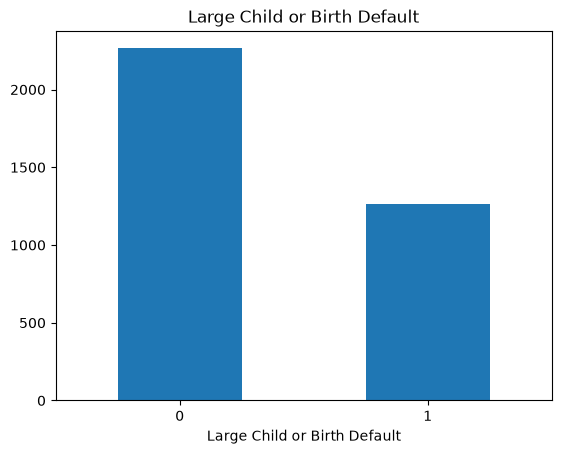

PCOS
0    2592
1     933
Name: count, dtype: int64

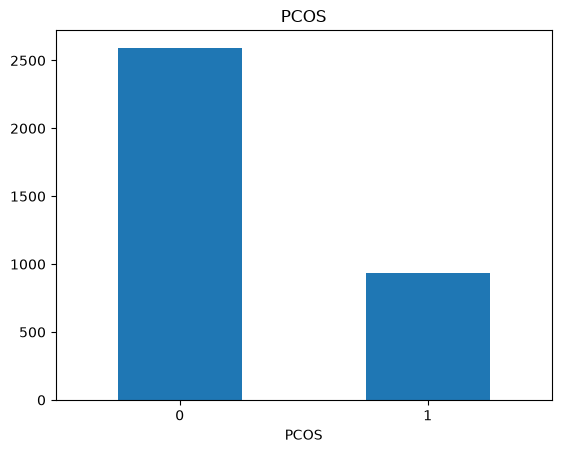

Sedentary Lifestyle
0    1940
1    1585
Name: count, dtype: int64

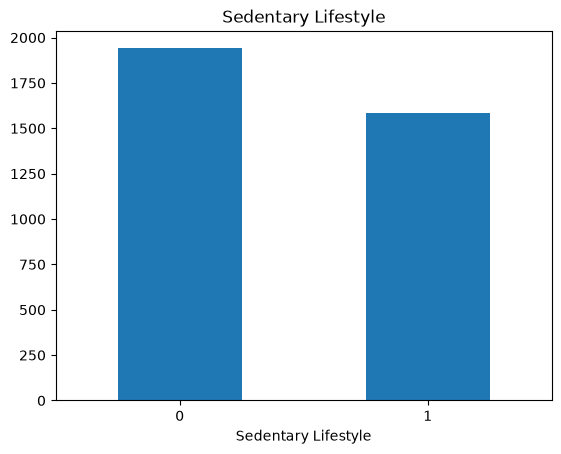

Prediabetes
0    2492
1    1033
Name: count, dtype: int64

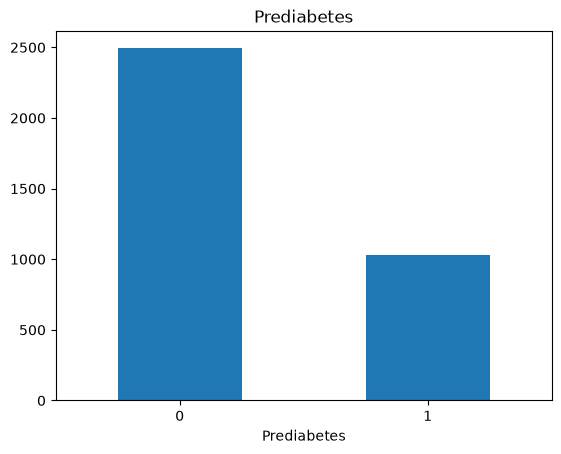

In [87]:
binary = [
    "Family History",
    "unexplained prenetal loss",
    "Large Child or Birth Default",
    "PCOS",
    "Sedentary Lifestyle",
    "Prediabetes"
]

for col in binary:

    counts = df[col].value_counts()

    display(counts)

    counts.plot(kind="bar")

    plt.title(col)

    plt.xticks(rotation=0)

    plt.show()

## Interpretation

The binary clinical risk factors exhibit a range of prevalences across the study population. `Family History` and `Sedentary Lifestyle` are the most common characteristics, each present in approximately half of the cohort. `Unexplained Prenatal Loss` and `Large Child or Birth Default` are present in approximately one-third of pregnancies, while `PCOS` and `Prediabetes` are less common.

None of the binary variables are extremely rare or overwhelmingly prevalent. Each variable therefore contains sufficient variation for subsequent comparisons with gestational diabetes status and potential inclusion in predictive models.

## Key Finding 3 — Binary Variables

Binary clinical risk factors vary meaningfully across the cohort, with prevalence ranging from approximately 27% to 50%. No predictor exhibits extreme imbalance, indicating that each has sufficient variation for further analysis.

## Investigation 4 — Relationship with GDM

## Question

How do predictor variables differ between pregnancies with and without gestational diabetes?

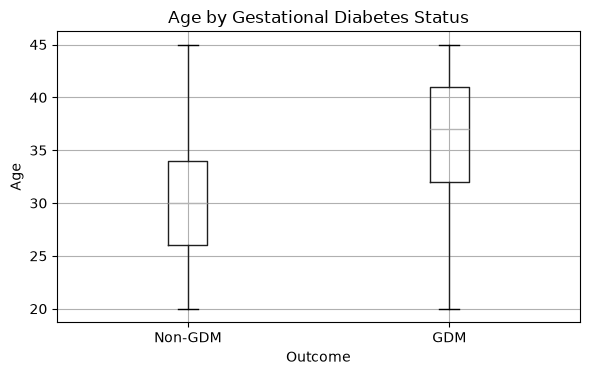

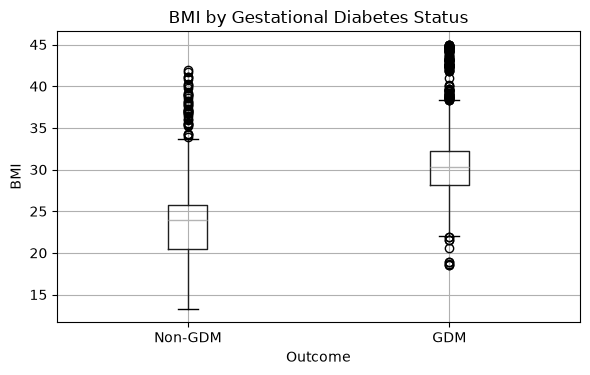

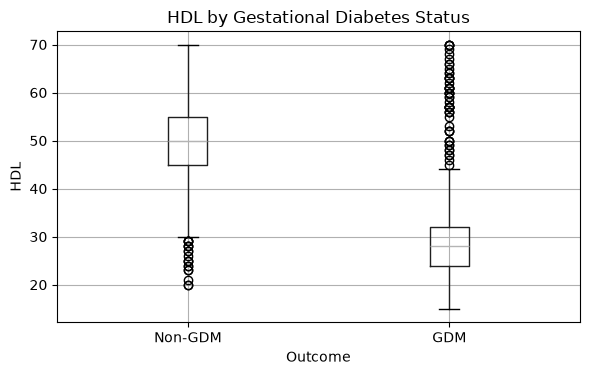

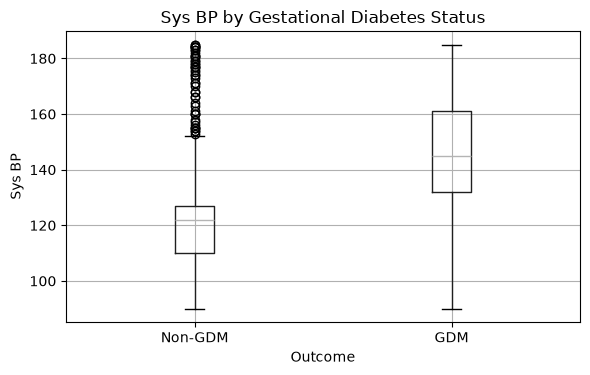

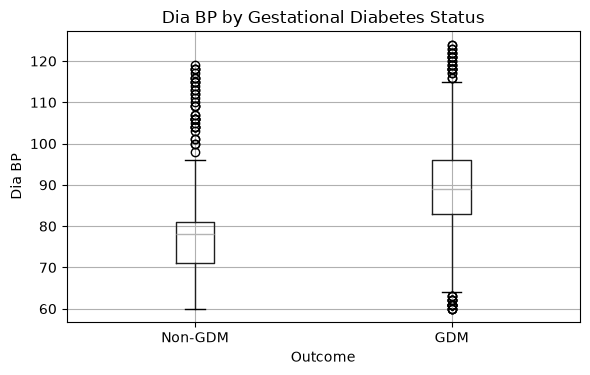

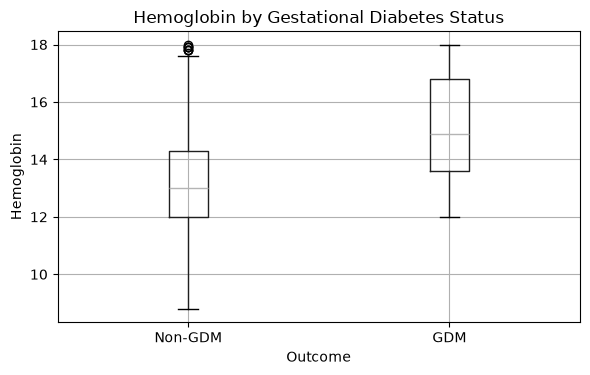

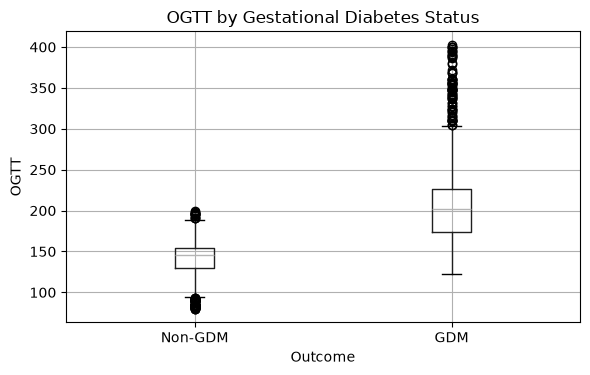

In [88]:
for col in continuous:
    ax = df.boxplot(
        column=col,
        by=target,
        figsize=(6, 4),
    )

    ax.set_title(f"{col} by Gestational Diabetes Status")
    ax.set_xlabel("Outcome")
    ax.set_ylabel(col)
    ax.set_xticklabels(["Non-GDM", "GDM"])

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

In [89]:
continuous_by_outcome = (
    df.groupby(target)[continuous]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

continuous_by_outcome

Age                       BMI                      \
                          count   mean median   std count   mean median   std   
Class Label(GDM /Non GDM)                                                       
0                          2153  30.38   30.0  5.22  1072  23.69   24.0  4.24   
1                          1372  36.03   37.0  5.97  1372  31.11   30.3  4.48   

                            HDL         ... Dia BP        Hemoglobin         \
                          count   mean  ... median    std      count   mean   
Class Label(GDM /Non GDM)               ...                                   
0                          2101  49.66  ...   78.0   8.13       2153  13.24   
1                           423  30.62  ...   89.0  10.83       1372  15.08   

                                        OGTT                        
                          median   std count    mean median    std  
Class Label(GDM /Non GDM)                                           
0                           13.0  1.53  1640  140.32  146.0  19.95  
1                           14.9  1.79  1372  207.03  202.0  46.84  

[2 rows x 28 columns]

In [90]:
binary_gdm_tables = []

for col in binary:
    comparison = pd.crosstab(
        df[col],
        df[target],
        normalize="index"
    ).mul(100).round(1)

    comparison.columns = ["Non-GDM (%)", "GDM (%)"]
    comparison.index.name = col

    binary_gdm_tables.append(f"<h4>{col}</h4>")
    binary_gdm_tables.append(comparison.to_html())

html = f"""
<div style="height:500px; overflow-y:auto; border:1px solid #ccc; padding:10px;">
{''.join(binary_gdm_tables)}
</div>
"""

display(HTML(html))

,Non-GDM (%),GDM (%)
Family History,,
0,77.8,22.2
1,44.2,55.8
,Non-GDM (%),GDM (%)
unexplained prenetal loss,,
0,69.4,30.6
1,46.7,53.3
,Non-GDM (%),GDM (%)
Large Child or Birth Default,,
0,73.7,26.3


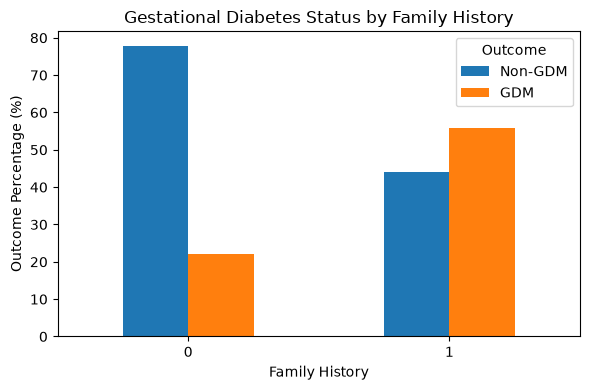

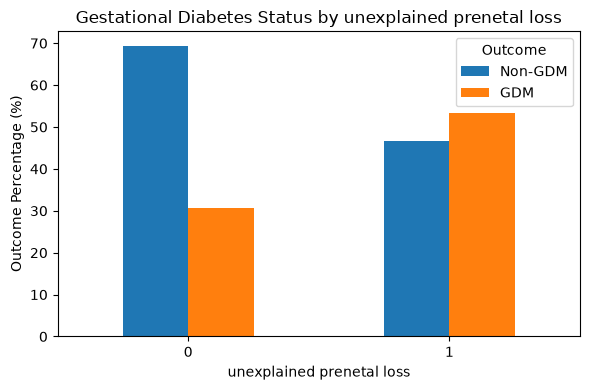

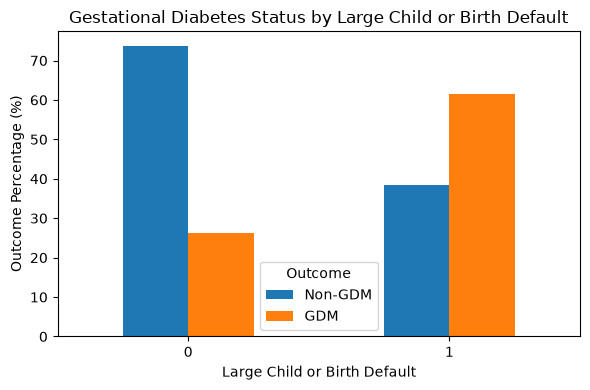

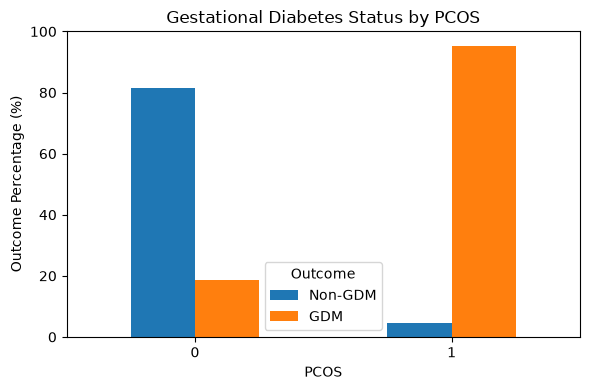

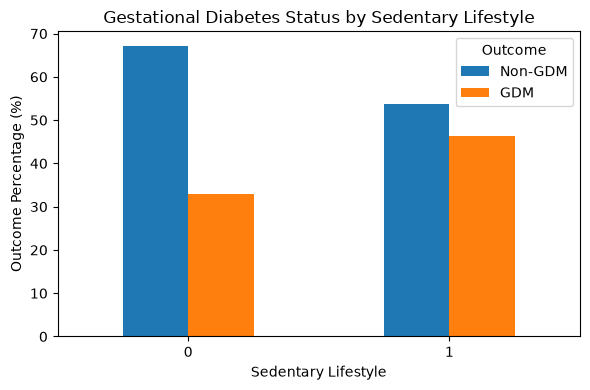

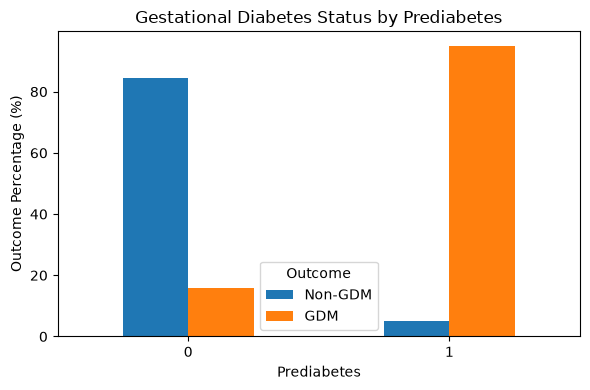

In [91]:
for col in binary:
    comparison = pd.crosstab(
        df[col],
        df[target],
        normalize="index"
    ).mul(100)

    comparison.columns = ["Non-GDM", "GDM"]

    comparison.plot(
        kind="bar",
        figsize=(6, 4)
    )

    plt.title(f"Gestational Diabetes Status by {col}")
    plt.xlabel(col)
    plt.ylabel("Outcome Percentage (%)")
    plt.xticks(rotation=0)
    plt.legend(title="Outcome")
    plt.tight_layout()
    plt.show()

## Interpretation

Several continuous and binary predictors demonstrate clear descriptive differences between pregnancies with and without gestational diabetes. Maternal age, BMI, systolic blood pressure, diastolic blood pressure, hemoglobin, and OGTT measurements are generally higher among women diagnosed with gestational diabetes, whereas HDL cholesterol tends to be lower.

Among the binary variables, Family History, Large Child or Birth Default, PCOS, Prediabetes, Sedentary Lifestyle, and Unexplained Prenatal Loss are all associated with higher proportions of gestational diabetes. The strongest descriptive relationships are observed for OGTT, Prediabetes, and PCOS.

Although many predictors exhibit noticeable separation between outcome groups, considerable overlap remains for several continuous variables. These findings suggest that accurate prediction will likely require combining multiple maternal characteristics rather than relying on any single clinical measurement.

## Key Finding 4 — Relationships with Gestational Diabetes

Both continuous and binary clinical predictors demonstrate meaningful differences between pregnancies with and without gestational diabetes. Higher maternal age, BMI, blood pressure, hemoglobin, and OGTT measurements, together with the presence of several established clinical risk factors, are associated with increased proportions of gestational diabetes. These findings indicate that the dataset contains multiple informative predictors that can be evaluated during subsequent model development.

## Investigation 5 — Correlation Structure

## Question

How strongly are the continuous predictors related to one another?

In [92]:
corr = df[continuous].corr()

display(corr)

,Age,BMI,HDL,Sys BP,Dia BP,Hemoglobin,OGTT
Age,1.000000,0.516200,-0.444572,0.619515,0.481878,0.288387,0.383144
BMI,0.516200,1.000000,-0.694974,0.245677,0.541788,0.220607,0.758952
HDL,-0.444572,-0.694974,1.000000,-0.629794,-0.581466,-0.125162,-0.697259
Sys BP,0.619515,0.245677,-0.629794,1.000000,0.584059,0.331778,0.322453
Dia BP,0.481878,0.541788,-0.581466,0.584059,1.000000,0.324537,0.460497
Hemoglobin,0.288387,0.220607,-0.125162,0.331778,0.324537,1.000000,0.237489
OGTT,0.383144,0.758952,-0.697259,0.322453,0.460497,0.237489,1.000000


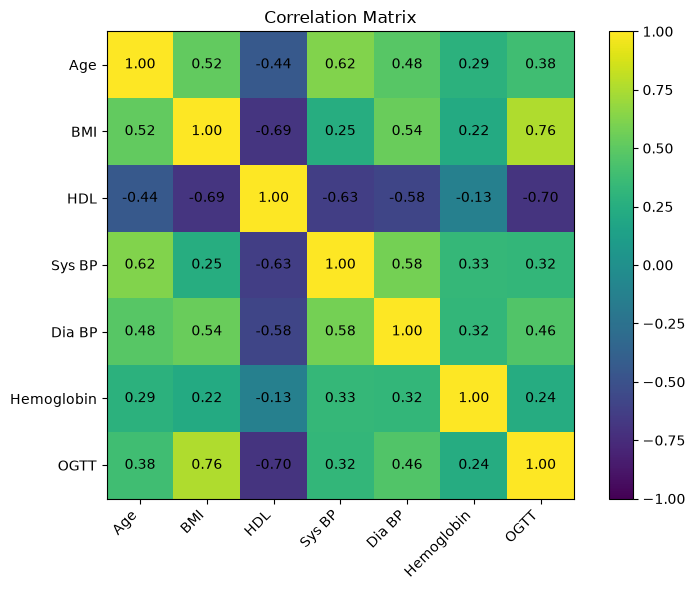

In [93]:
fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(corr, vmin=-1, vmax=1)
fig.colorbar(image, ax=ax)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")

ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

for row in range(len(corr.index)):
    for col in range(len(corr.columns)):
        ax.text(
            col,
            row,
            f"{corr.iloc[row, col]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Interpretation

The correlation matrix reveals several moderate-to-strong relationships among the continuous clinical variables. BMI is strongly positively correlated with OGTT (r = 0.76) and strongly negatively correlated with HDL (r = -0.69). HDL also demonstrates moderate negative correlations with both systolic blood pressure (r = -0.63) and OGTT (r = -0.70).

Maternal age is moderately positively correlated with systolic blood pressure (r = 0.62) and BMI (r = 0.52), while systolic and diastolic blood pressure exhibit the expected moderate positive correlation (r = 0.58).

These relationships are clinically plausible and do not necessarily indicate problematic multicollinearity. However, they should be monitored during model development, particularly for interpretable models such as Logistic Regression, where correlated predictors can influence coefficient stability and interpretation.

## Key Finding 5 — Correlation Structure

Several continuous predictors exhibit moderate-to-strong correlations, particularly among BMI, HDL, OGTT, and blood pressure measurements. These relationships reflect expected clinical associations and should be considered during model development, but they do not justify removing variables at this stage.

## Investigation 6 — Missingness and Outcome

## Question

Are patients with missing clinical measurements systematically different from those with complete data?

In [94]:
for col in ["BMI","HDL","Sys BP","OGTT"]:

    print(col)

    display(
        pd.crosstab(
            df[col].isna(),
            df[target],
            normalize="index"
        )
    )

BMI


Class Label(GDM /Non GDM),0,1
BMI,,
False,0.438625,0.561375
True,1.000000,0.000000


HDL


Class Label(GDM /Non GDM),0,1
HDL,,
False,0.832409,0.167591
True,0.051948,0.948052


Sys BP


Class Label(GDM /Non GDM),0,1
Sys BP,,
False,0.385165,0.614835
True,0.851613,0.148387


OGTT


Class Label(GDM /Non GDM),0,1
OGTT,,
False,0.544489,0.455511
True,1.000000,0.000000


## Interpretation

The distribution of gestational diabetes differs substantially between patients with observed and missing values for BMI, HDL, systolic blood pressure, and OGTT. In some variables, one outcome group contains no missing observations, demonstrating a strong relationship between measurement availability and GDM status.

These findings reinforce the conclusion that missingness is not completely random. Missingness indicators may therefore preserve useful information during modeling, although their predictive contribution must be interpreted cautiously because the pattern could reflect how the dataset was collected or constructed rather than an underlying clinical mechanism.

## Key Finding 5 — Correlation Structure

Several continuous predictors exhibit moderate-to-strong correlations, particularly among BMI, HDL, OGTT, and blood pressure measurements. These relationships reflect expected clinical associations and should be considered during model development, but they do not justify removing variables at this stage.

## Summary of Findings

Exploratory analysis identified several clinical variables that demonstrate meaningful associations with gestational diabetes, particularly maternal age, BMI, and OGTT measurements. Although differences between outcome groups were observed, substantial overlap suggests that accurate prediction will require combining multiple predictors within a multivariable model.

Binary clinical risk factors varied considerably in prevalence, with some occurring relatively infrequently. Correlation analysis identified several moderate-to-strong relationships among continuous predictors, particularly involving BMI, HDL, OGTT, and blood pressure measurements. These findings are clinically plausible and will be considered during subsequent feature engineering and model development.

Overall, the exploratory analysis demonstrates that the dataset contains clinically meaningful patterns suitable for predictive modeling while highlighting areas for careful feature engineering and preprocessing.

## Next Steps

The insights gained from this exploratory analysis will guide preparation of the modeling dataset.

Planned activities include:

- Reviewing feature selection in light of exploratory findings.
- Applying feature scaling where appropriate.
- Constructing a stratified train-test split.
- Building reproducible preprocessing pipelines.
- Developing and evaluating a baseline Logistic Regression model.